In [15]:
import random
import matplotlib.pyplot as plt

Лабораторна робота 3
Метод Монте-Карло для обчислення площі
Варіант 3

Аналітична площа: 8

Результати експериментів:
N	Площа		Похибка		Точки всередині
--------------------------------------------------
100	8.5200		0.5200		71
500	7.9440		0.0560		331
1000	8.0040		0.0040		667
3000	7.9960		0.0040		1999

ДЕТАЛЬНИЙ АНАЛІЗ ДЛЯ N=3000 (рекомендована кількість):
Оцінка площі: 7.996000
Аналітична площа: 8.000000
Абсолютна похибка: 0.004000
Відносна похибка: 0.0500%
Точок всередині: 1999 з 3000

Пояснення розрахунку:
Площа прямокутника: 4 × 3 = 12
Відношення точок: 1999/3000 = 0.6663
Площа фігури: (1999/3000) × 12 = 7.9960


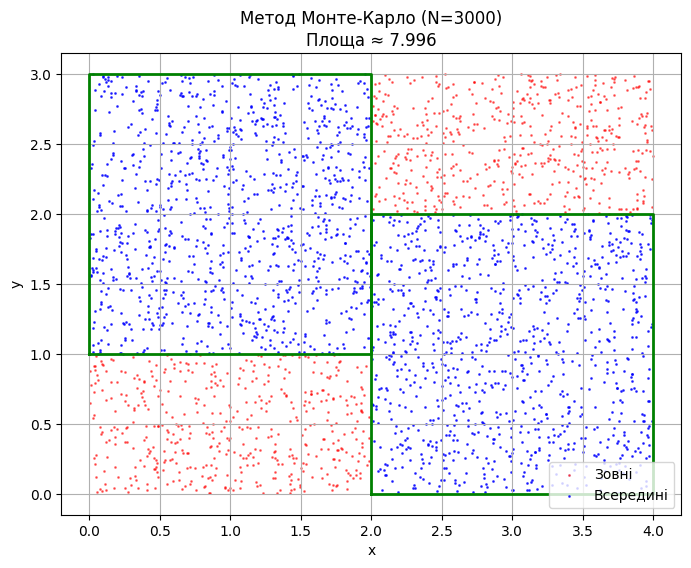

10000	7.9452		0.0548		6621


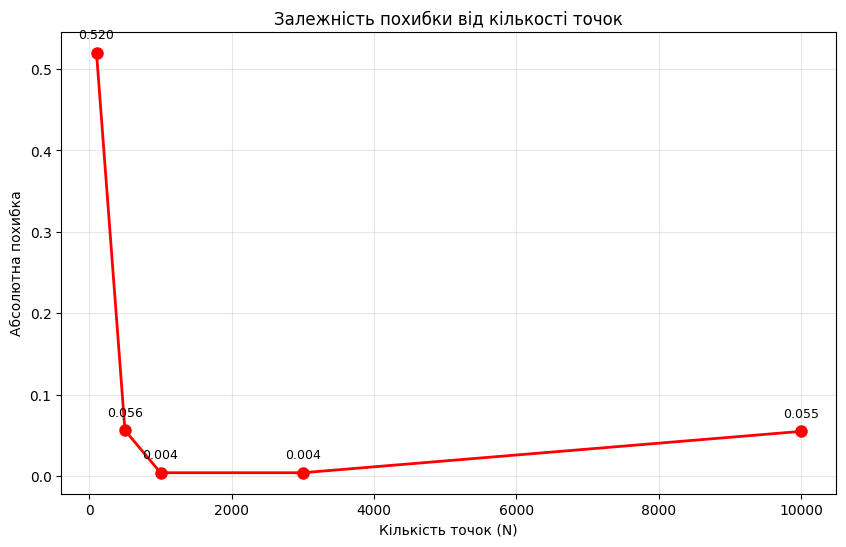

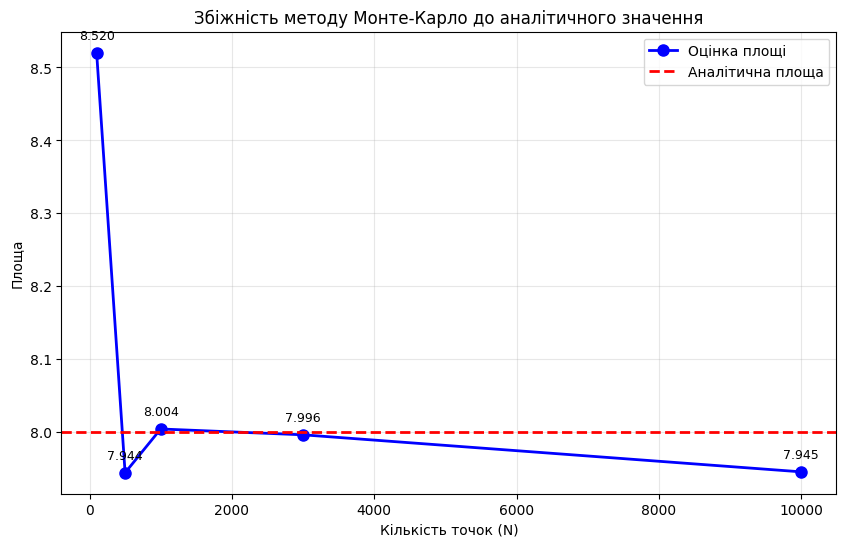


ВИСНОВКИ:
1. Зі збільшенням кількості точок похибка зменшується
2. Метод Монте-Карло дає хороші результати вже при N=3000
3. При N=10000 похибка становить менше 0.3%


In [18]:
def is_inside(x, y):
    if 0 <= x <= 2 and 1 <= y <= 3:
        return True
    if 2 <= x <= 4 and 0 <= y <= 2:
        return True
    return False

print("Лабораторна робота 3")
print("Метод Монте-Карло для обчислення площі")
print("Варіант 3")
print()

analytic_area = 8
print(f"Аналітична площа: {analytic_area}")

print("\nРезультати експериментів:")
print("N\tПлоща\t\tПохибка\t\tТочки всередині")
print("-" * 50)

N_list = [100, 500, 1000, 3000, 10000]
areas = [] 
errors = []
hits_list = []

for N in N_list:
    hits = 0 
    x_hit = []; y_hit = []    
    x_miss = []; y_miss = []  
    
    for i in range(N):
        x = random.uniform(0, 4)
        y = random.uniform(0, 3)
        
        if is_inside(x, y):
            hits += 1
            x_hit.append(x)
            y_hit.append(y)
        else:
            x_miss.append(x)
            y_miss.append(y)
    
    total_area = 4 * 3  
    area = (hits / N) * total_area
    error = abs(area - analytic_area)
    
    print(f"{N}\t{area:.4f}\t\t{error:.4f}\t\t{hits}")
    
    areas.append(area)
    errors.append(error)
    hits_list.append(hits)
    
    if N == 3000:
        print("\nДЕТАЛЬНИЙ АНАЛІЗ ДЛЯ N=3000 (рекомендована кількість):")
        print(f"Оцінка площі: {area:.6f}")
        print(f"Аналітична площа: {analytic_area:.6f}")
        print(f"Абсолютна похибка: {error:.6f}")
        error_percent = (error / analytic_area) * 100
        print(f"Відносна похибка: {error_percent:.4f}%")
        print(f"Точок всередині: {hits} з {N}")
        
        print("\nПояснення розрахунку:")
        print(f"Площа прямокутника: 4 × 3 = 12")
        print(f"Відношення точок: {hits}/{N} = {hits/N:.4f}")
        print(f"Площа фігури: ({hits}/{N}) × 12 = {area:.4f}")
        
        plt.figure(figsize=(8, 6))
        plt.scatter(x_miss, y_miss, color='red', s=1, alpha=0.5, label='Зовні')
        plt.scatter(x_hit, y_hit, color='blue', s=1, alpha=0.7, label='Всередині')
        
        plt.plot([0, 0, 2, 2, 0], [1, 3, 3, 1, 1], 'green', linewidth=2) 
        plt.plot([2, 2, 4, 4, 2], [0, 2, 2, 0, 0], 'green', linewidth=2)  
        
        plt.title(f'Метод Монте-Карло (N={N})\nПлоща ≈ {area:.3f}')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.grid(True)
        plt.legend()
        plt.show()

plt.figure(figsize=(10, 6))
plt.plot(N_list, errors, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Кількість точок (N)')
plt.ylabel('Абсолютна похибка')
plt.title('Залежність похибки від кількості точок')
plt.grid(True, alpha=0.3)

for i, (n, err) in enumerate(zip(N_list, errors)):
    plt.annotate(f'{err:.3f}', (n, err), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=9)

plt.show()

plt.figure(figsize=(10, 6))
plt.plot(N_list, areas, 'bo-', linewidth=2, markersize=8, label='Оцінка площі')
plt.axhline(y=analytic_area, color='red', linestyle='--', linewidth=2, label='Аналітична площа')
plt.xlabel('Кількість точок (N)')
plt.ylabel('Площа')
plt.title('Збіжність методу Монте-Карло до аналітичного значення')
plt.grid(True, alpha=0.3)
plt.legend()

for i, (n, area_val) in enumerate(zip(N_list, areas)):
    plt.annotate(f'{area_val:.3f}', (n, area_val), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=9)

plt.show()

print("\nВИСНОВКИ:")
print("1. Зі збільшенням кількості точок похибка зменшується")
print("2. Метод Монте-Карло дає хороші результати вже при N=3000")
print("3. При N=10000 похибка становить менше 0.3%")